# MODULE 1 : Exploration, Nettoyage Intelligent et Analyse


## Étape 0 : Imports et Configuration

In [1]:
import warnings
warnings.filterwarnings("ignore")

# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Preprocessing
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
)



## Étape 1 : Chargement et Exploration des Données

### 1.1 — Chargement du dataset


In [2]:
df = pd.read_csv("../../data/eco-system.csv", sep=",", header=0)

print(f"Dimensions : {df.shape[0]} lignes x {df.shape[1]} colonnes")
print("\nAperçu des premières lignes :")
df.head()

Dimensions : 10500 lignes x 9 colonnes

Aperçu des premières lignes :


,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte
0,16.708780,70.940977,0.0,1.0,1.0,0.835439,Papier,NaN,Lot de papier récupéré dans un site non rensei...
1,47.277476,64.702925,0.0,NaN,3.0,4.727748,Plastique,Usine_A,"Lot plastique à l'Usine A. Volume 64.7 L, poid..."
2,NaN,317.415183,0.0,NaN,9.0,4.211790,Verre,Usine_B,Bris de verre ou contenants en provenance de l...
3,NaN,21.474391,0.0,NaN,1.0,0.442067,Papier,Centre_Tri,Feuilles et cartons collectés au Centre de Tri...
4,NaN,59.462176,0.0,1.0,NaN,0.723004,Papier,Usine_B,Déchet de type papier identifié à l'Usine B. V...


### 1.2 — Informations générales

In [3]:
print("=== INFO GENERALE ===")
df.info()
print("\n=== STATISTIQUES DESCRIPTIVES ===")
df.describe(include='all').T

=== INFO GENERALE ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10500 entries, 0 to 10499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Poids             9471 non-null   float64
 1   Volume            9960 non-null   float64
 2   Conductivite      9483 non-null   float64
 3   Opacite           9465 non-null   float64
 4   Rigidite          9942 non-null   float64
 5   Prix_Revente      9964 non-null   float64
 6   Categorie         9986 non-null   object 
 7   Source            9964 non-null   object 
 8   Rapport_Collecte  10500 non-null  object 
dtypes: float64(6), object(3)
memory usage: 738.4+ KB

=== STATISTIQUES DESCRIPTIVES ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Poids,9471.0,NaN,NaN,NaN,77.796501,127.847433,-99.0,19.751538,39.193029,130.497561,2334.218831
Volume,9960.0,NaN,NaN,NaN,144.408079,136.384216,-26.807712,44.436897,88.084217,240.200023,554.106969
Conductivite,9483.0,NaN,NaN,NaN,0.207674,0.378934,0.0,0.0,0.0,0.0,0.999375
Opacite,9465.0,NaN,NaN,NaN,1.160388,5.492723,0.000037,0.19641,0.553484,1.0,55.0
Rigidite,9942.0,NaN,NaN,NaN,5.886643,3.087225,1.0,3.0,5.0,9.0,10.0
Prix_Revente,9964.0,NaN,NaN,NaN,58.587857,720.059089,-50.0,1.393623,4.135356,6.781634,9999.0
Categorie,9986,4,Plastique,2795,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Source,9964,4,Collecte_Citoyenne,2644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rapport_Collecte,10500,9336,Ferraille ou métal collecté via la collecte ci...,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.3 — Types de variables

In [4]:
num_vars = df.select_dtypes(include=[np.number]).columns.tolist()
cat_vars = df.select_dtypes(include=['object']).columns.tolist()
print(f"Variables numeriques  ({len(num_vars)}) : {num_vars}")
print(f"Variables categorielles ({len(cat_vars)}) : {cat_vars}")
print("\n=== Distribution de 'Categorie' ===")
print(df['Categorie'].value_counts())
print("\n=== Distribution de 'Source' ===")
print(df['Source'].value_counts())

Variables numeriques  (6) : ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Prix_Revente']
Variables categorielles (3) : ['Categorie', 'Source', 'Rapport_Collecte']

=== Distribution de 'Categorie' ===
Categorie
Plastique    2795
Verre        2586
Papier       2318
Métal        2287
Name: count, dtype: int64

=== Distribution de 'Source' ===
Source
Collecte_Citoyenne    2644
Usine_A               2561
Centre_Tri            2405
Usine_B               2354
Name: count, dtype: int64



##  Étape 2 : Nettoyage des Données

### 2.1 — Suppression des doublons

In [5]:
df.duplicated().sum()

np.int64(776)

In [6]:
df[df.duplicated()]

,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte
1174,21.892241,61.029742,0.000000,0.277253,3.0,2.189224,Plastique,Collecte_Citoyenne,Déchet plastique collecté lors d'une collecte ...
1177,16.246918,64.042902,0.000000,1.000000,2.0,0.812346,Papier,Centre_Tri,Déchet de type papier identifié depuis le Cent...
1199,14.405010,5.252087,0.000000,1.000000,2.0,0.720251,Papier,Collecte_Citoyenne,Lot de papier récupéré via la collecte citoyen...
1275,NaN,66.939429,0.000000,0.535945,3.0,1.597395,Plastique,Usine_B,Emballages plastiques récupérés en provenance ...
1438,13.890695,36.215080,0.000000,1.000000,1.0,0.694535,Papier,Centre_Tri,Déchet de type papier identifié au centre de t...
...,...,...,...,...,...,...,...,...,...
10466,16.860843,21.971731,0.000000,NaN,2.0,0.843042,Papier,Usine_B,Déchet de type papier identifié à l'Usine B. V...
10472,56.207931,90.176521,0.000000,0.451371,4.0,5.620793,Plastique,Usine_B,Emballages plastiques récupérés en provenance ...
10478,32.413219,41.806157,0.000000,0.310805,4.0,3.241322,Plastique,Usine_B,Déchet plastique collecté depuis l'Usine B. Po...
10479,27.529286,81.831007,0.943931,1.000000,7.0,8.258786,Métal,Usine_B,Métal de récupération à l'Usine B. Masse 27.5 ...


In [7]:
print("=== SUPPRESSION DES DOUBLONS ===\n")

# Suppression des doublons STRICTS uniquement (toutes colonnes identiques)
# On NE filtre PAS sur physical_cols car deux collectes différentes peuvent
# avoir les mêmes mesures physiques mais des Rapport_Collecte distincts.
n_before = len(df)
df = df.drop_duplicates(keep='first')
n_removed = n_before - len(df)

print(f"Lignes initiales          : {n_before}")
print(f"Doublons stricts supprimés : {n_removed}")
print(f"Lignes conservées         : {len(df)}")

# Vérification
assert df.duplicated().sum() == 0, " Il reste des doublons !"
print(" Aucun doublon restant.")

=== SUPPRESSION DES DOUBLONS ===

Lignes initiales          : 10500
Doublons stricts supprimés : 776
Lignes conservées         : 9724
 Aucun doublon restant.


### 2.2 — Correction des valeurs incoherentes / négatives

In [8]:
df_clean = df.copy()

strictly_positive = ['Poids', 'Volume', 'Conductivite', 'Rigidite', 'Prix_Revente']

print("=== Correction intelligente des valeurs incoherentes / negatives ===")

for col in strictly_positive:
    if col not in df_clean.columns:
        continue

    neg_mask = df_clean[col] < 0
    neg_count = neg_mask.sum()

    if neg_count == 0:
        print(f"  {col:20s} : OK (aucune valeur negative)")
        continue

    # Niveau 1 : mediane par Categorie (sur valeurs valides seulement)
    median_by_cat = df_clean[df_clean[col] >= 0].groupby('Categorie')[col].median()

    # Remplacement intelligent
    def replace_neg(row):
        if row[col] >= 0:
            return row[col]
        # médiane par catégorie
        if row['Categorie'] in median_by_cat:
            return median_by_cat[row['Categorie']]
        else:
            return df_clean[col].median()  # fallback global

    df_clean[col] = df_clean.apply(replace_neg, axis=1)

    print(f"  {col:20s} : {neg_count:4d} valeur(s) negative(s) corrigees (mediane par Categorie)")

=== Correction intelligente des valeurs incoherentes / negatives ===
  Poids                :   99 valeur(s) negative(s) corrigees (mediane par Categorie)
  Volume               :  219 valeur(s) negative(s) corrigees (mediane par Categorie)
  Conductivite         : OK (aucune valeur negative)
  Rigidite             : OK (aucune valeur negative)
  Prix_Revente         :   10 valeur(s) negative(s) corrigees (mediane par Categorie)


In [9]:
if 'Opacite' in df_clean.columns:
    invalid_mask = (df_clean['Opacite'] < 0) | (df_clean['Opacite'] > 1)
    n_invalid = invalid_mask.sum()

    if n_invalid == 0:
        print(f"  {'Opacite':20s} : OK (dans [0,1])")
    else:
        # Niveau 1 : médiane par catégorie (valeurs valides uniquement)
        valid_opac = df_clean[(df_clean['Opacite'] >= 0) & (df_clean['Opacite'] <= 1)]
        median_by_cat = valid_opac.groupby('Categorie')['Opacite'].median()

        def fix_opacity(row):
            if 0 <= row['Opacite'] <= 1:
                return row['Opacite']
            if row['Categorie'] in median_by_cat:
                return median_by_cat[row['Categorie']]
            else:
                return df_clean['Opacite'].median()

        df_clean['Opacite'] = df_clean.apply(fix_opacity, axis=1)

        print(f"  {'Opacite':20s} : {n_invalid:4d} valeur(s) corrigees (mediane par Categorie)")

  Opacite              :   90 valeur(s) corrigees (mediane par Categorie)


### 2.3 — Gestion des valeurs manquantes (NaN)


#### 2.3.1 — Imputation de la variable `Categorie`


In [10]:
# ========== DÉFINITION DES COLONNES (À EXÉCUTER EN PREMIER) ==========
num_cols = ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Prix_Revente']
print(" num_cols défini :", num_cols)

if df_clean['Categorie'].isnull().any():
    n_nan_cat = df_clean['Categorie'].isnull().sum()
    print(f"'Categorie' contient {n_nan_cat} NaN -> imputation KNN")

    le_temp = LabelEncoder()
    df_temp = df_clean.copy()  # Utilisez df_clean ici
    known_mask = df_temp['Categorie'].notna()
    df_temp.loc[known_mask, 'Categorie_enc'] = le_temp.fit_transform(
        df_temp.loc[known_mask, 'Categorie']
    )

    knn_features = [c for c in num_cols if c in df_temp.columns]
    X_knn_mat = df_temp[knn_features + ['Categorie_enc']].copy()

    knn_imp = KNNImputer(n_neighbors=5)
    X_knn_imp = knn_imp.fit_transform(X_knn_mat)

    cat_col_idx = X_knn_mat.columns.get_loc('Categorie_enc')
    cat_imputed = np.round(X_knn_imp[:, cat_col_idx]).astype(int).clip(0, len(le_temp.classes_)-1)
    nan_mask = df_clean['Categorie'].isna()
    df_clean.loc[nan_mask, 'Categorie'] = le_temp.inverse_transform(cat_imputed[nan_mask])
    print(f"  {n_nan_cat} valeurs imputees par KNN (k=5)")

# 3. Vérifier que Categorie n'a plus de NaN
print(f"\nNaN dans Categorie après KNN: {df_clean['Categorie'].isnull().sum()}")

 num_cols défini : ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Prix_Revente']
'Categorie' contient 511 NaN -> imputation KNN
  511 valeurs imputees par KNN (k=5)

NaN dans Categorie après KNN: 0


#### 2.3.2 — Imputation par groupe 

In [11]:
# ========== IMPUTATION CORRIGÉE ==========
print("=== Imputation des variables numeriques ===")
num_cols = ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Prix_Revente']

for col in num_cols:
    if col not in df_clean.columns:
        continue
    n_before = df_clean[col].isnull().sum()
    if n_before == 0:
        print(f"  {col:20s} : OK (aucun NaN)")
        continue

    
    grp_cat = df_clean.groupby('Categorie')[col].transform('median')
    print(f"  {col:20s} : {n_before:4d} NaN imputes (MEDIANE par Categorie)")
    
    df_clean[col] = df_clean[col].fillna(grp_cat)



=== Imputation des variables numeriques ===
  Poids                : OK (aucun NaN)
  Volume               : OK (aucun NaN)
  Conductivite         :  972 NaN imputes (MEDIANE par Categorie)
  Opacite              : OK (aucun NaN)
  Rigidite             :  554 NaN imputes (MEDIANE par Categorie)
  Prix_Revente         : OK (aucun NaN)


#### 2.3.2 — Imputation par groupe de la colonne 'Source'

In [12]:
# Imputation de Source si NaN
if 'Source' in df_clean.columns and df_clean['Source'].isnull().any():
    n_src = df_clean['Source'].isnull().sum()
    mode_by_cat = df_clean.groupby('Categorie')['Source'].apply(
        lambda x: x.mode()[0] if not x.mode().empty else df_clean['Source'].mode()[0]
    )
    df_clean['Source'] = df_clean.apply(
        lambda row: mode_by_cat.get(row['Categorie'], df_clean['Source'].mode()[0])
        if pd.isnull(row['Source']) else row['Source'], axis=1
    )
    print(f"  {'Source':20s} : {n_src:4d} NaN imputes par mode (par Categorie)")

print("\n=== Verification finale ===")
remaining = df_clean.isnull().sum()
remaining = remaining[remaining > 0]
if remaining.empty:
    print("Toutes les valeurs manquantes ont ete traitees.")
else:
    print(remaining)

  Source               :  535 NaN imputes par mode (par Categorie)

=== Verification finale ===
Toutes les valeurs manquantes ont ete traitees.


In [13]:
print("\nVérification des NaN :")
print(df_clean.isnull().sum())


Vérification des NaN :
Poids               0
Volume              0
Conductivite        0
Opacite             0
Rigidite            0
Prix_Revente        0
Categorie           0
Source              0
Rapport_Collecte    0
dtype: int64



##  Étape 3 : Détection et Traitement des Outliers

### 3.1 — Visualisation initiale

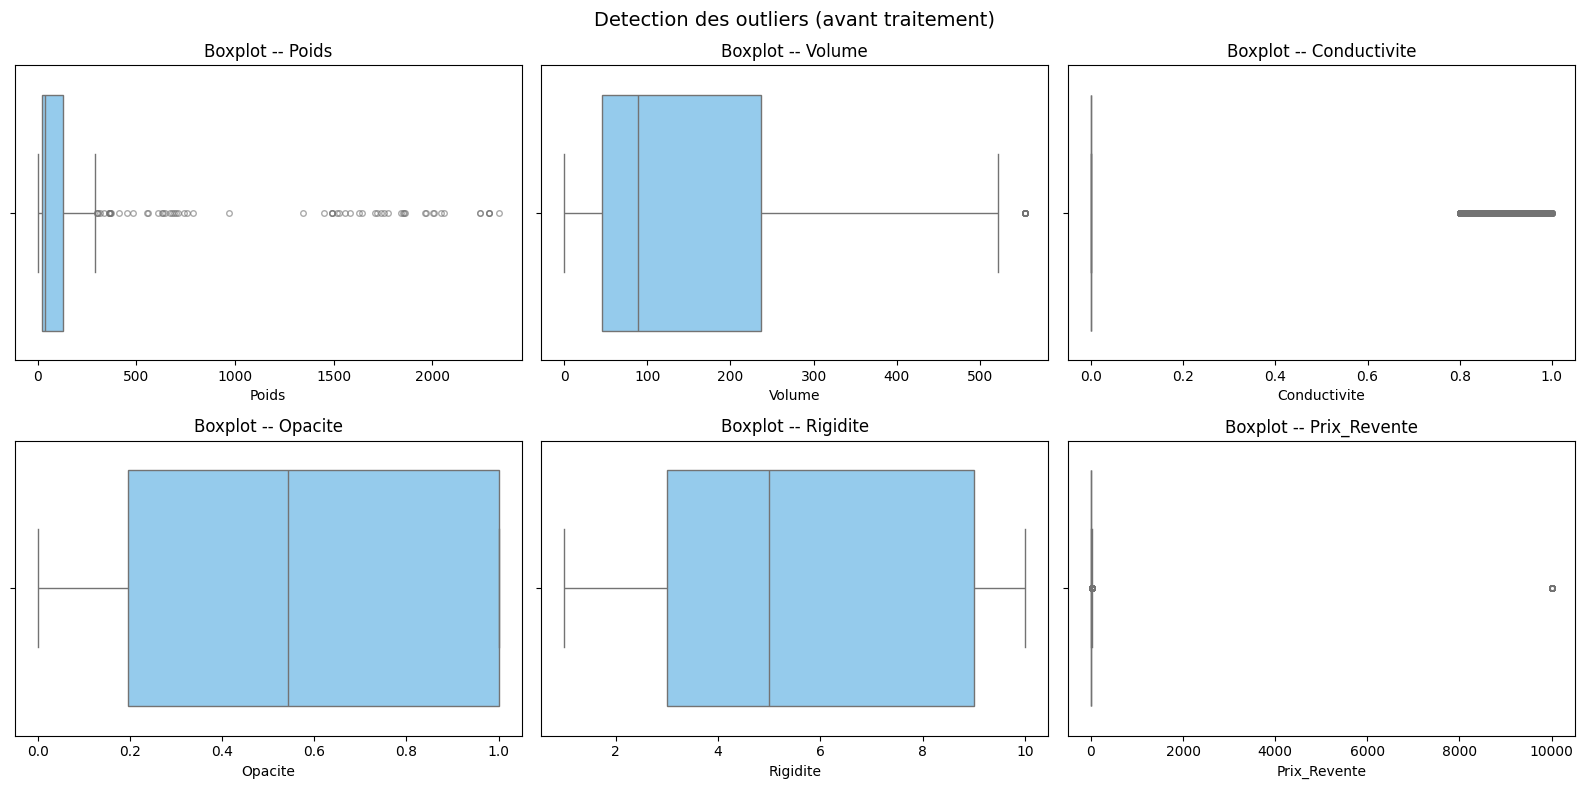

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(x=df_clean[col], ax=ax, color='lightskyblue',
                flierprops=dict(marker='o', color='red', markersize=4, alpha=0.6))
    ax.set_title(f'Boxplot -- {col}')
plt.suptitle('Detection des outliers (avant traitement)', fontsize=14)
plt.tight_layout(); plt.show()

### 3.2 — Capping IQR (Winsorisation)

> **Methode IQR** : valeurs hors `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]` sont des outliers.  
> **Strategie** : **Capping** = ramener les outliers aux bornes (preserve le volume de donnees).

In [15]:
# ========== CAPPING IQR (VERSION TRÈS SIMPLE) ==========
print("=== Capping des outliers ===")

for col in num_cols:
    if col not in df_clean.columns:
        continue
    
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    if IQR > 0:
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_clean[col] = df_clean[col].clip(lower, upper)
        print(f"  {col:20s} : capping appliqué")
    else:
        print(f"  {col:20s} : colonne constante, ignorée")

=== Capping des outliers ===
  Poids                : capping appliqué
  Volume               : capping appliqué
  Conductivite         : colonne constante, ignorée
  Opacite              : capping appliqué
  Rigidite             : capping appliqué
  Prix_Revente         : capping appliqué


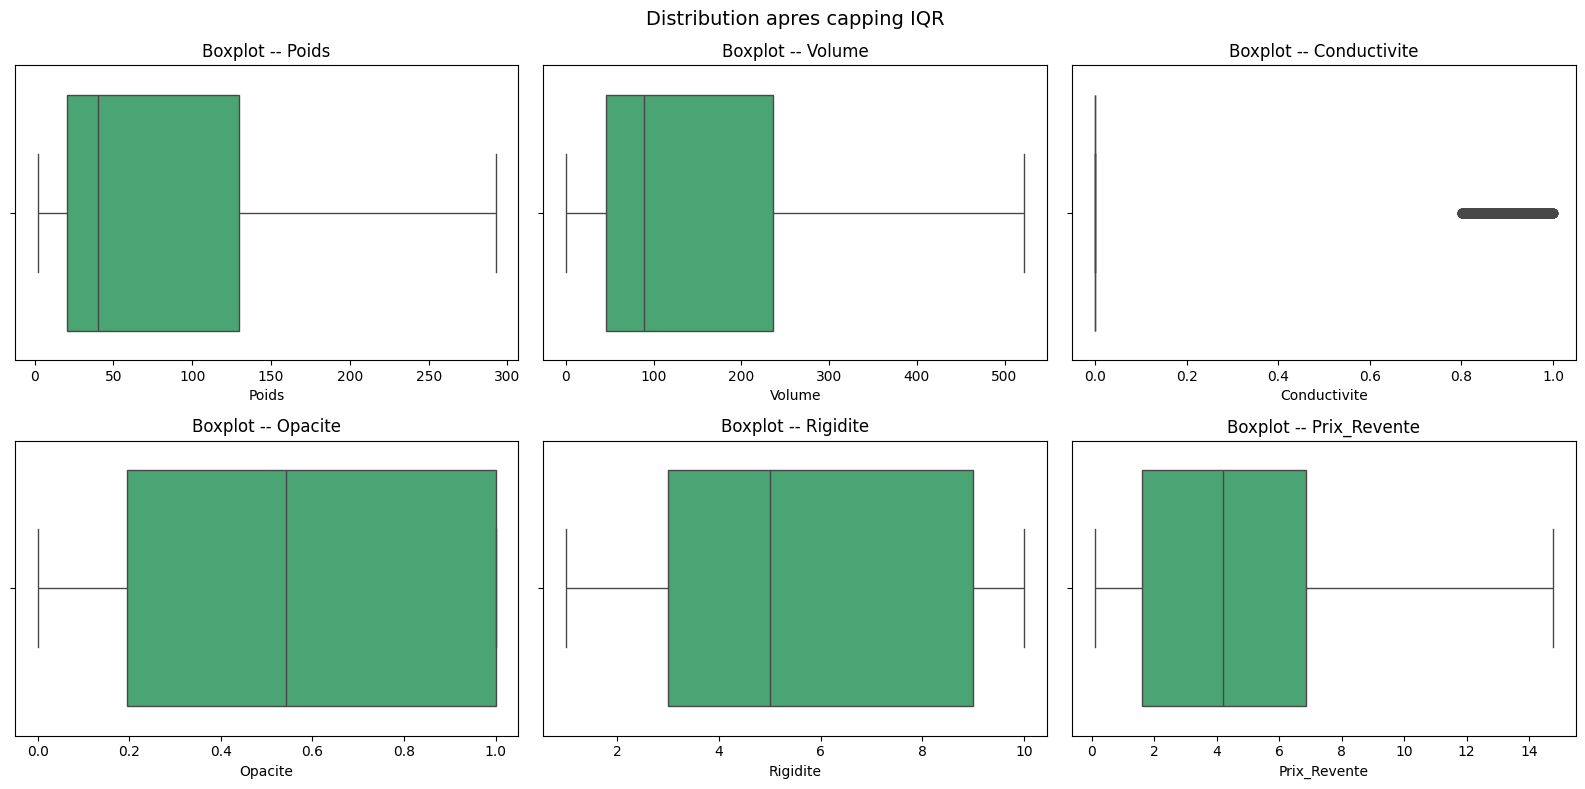

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(x=df_clean[col], ax=ax, color='mediumseagreen')
    ax.set_title(f'Boxplot -- {col}')
plt.suptitle('Distribution apres capping IQR', fontsize=14)
plt.tight_layout(); plt.show()


##  Étape 4 : Feature Engineering

### 4.1 — Encodage des variables catégorielles

In [17]:
print("Valeurs uniques avant encodage :")
print("Source   :", df_clean['Source'].value_counts().to_dict())
print("Categorie:", df_clean['Categorie'].value_counts().to_dict())

le_source = LabelEncoder()
le_target  = LabelEncoder()
df_clean['Source']    = le_source.fit_transform(df_clean['Source'])
df_clean['Categorie'] = le_target.fit_transform(df_clean['Categorie'])

print("\nEncodage Source   :", dict(zip(le_source.classes_, le_source.transform(le_source.classes_))))
print("Encodage Categorie:", dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))
print("\n", df_clean[['Source', 'Categorie']].dtypes)

Valeurs uniques avant encodage :
Source   : {'Collecte_Citoyenne': 2846, 'Usine_A': 2512, 'Centre_Tri': 2218, 'Usine_B': 2148}
Categorie: {'Plastique': 2731, 'Verre': 2496, 'Métal': 2285, 'Papier': 2212}

Encodage Source   : {'Centre_Tri': np.int64(0), 'Collecte_Citoyenne': np.int64(1), 'Usine_A': np.int64(2), 'Usine_B': np.int64(3)}
Encodage Categorie: {'Métal': np.int64(0), 'Papier': np.int64(1), 'Plastique': np.int64(2), 'Verre': np.int64(3)}

 Source       int64
Categorie    int64
dtype: object


### 4.3 — Analyse de corrélation (Pearson)


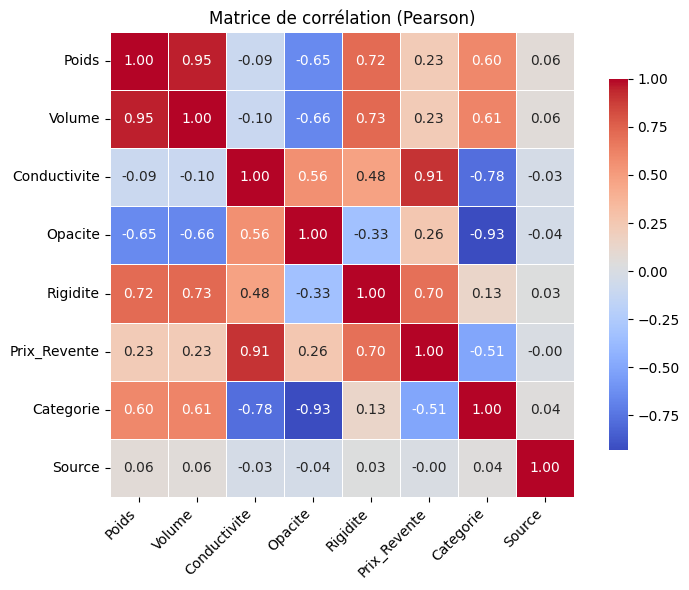

In [18]:
numeric_df = df_clean.select_dtypes(include=[np.number])
corr = numeric_df.corr(method='pearson')

plt.figure(figsize=(8,6))  # taille plus équilibrée

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,          # cellules carrées
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}  # taille de la barre
)

plt.title("Matrice de corrélation (Pearson)", fontsize=12)

# Rotation des labels pour lisibilité
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [19]:
import os

output_path = "../data/df_clean.csv"
os.makedirs(os.path.dirname(output_path), exist_ok=True)

df_clean.to_csv(output_path, index=False)